## **Sección 2**: *Tabu Search*

### 2.1 Implementación del algoritmo

> Implemente el algoritmo de *Tabu Search* utilizando **únicamente la lista tabú básica con tenure fijo**, sin estrategias avanzadas de intensificación/diversificación. Emplee como criterio de parada un número máximo de iteraciones $N_{\text{max}}$, y considere como criterio complementario el **Estancamiento**, deteniendo la búsqueda si no hay mejora en el mejor fitness durante $k$ iteraciones consecutivas. Puede encontrar más detalles del algoritmo en el **Anexo II**.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from auxiliar_eduardito import *
from IPython.display import clear_output
import time
import pandas as pd

In [25]:
class tabu_search():
    def __init__(self, function, start_point, lower, upper, k, n_vecinos, sigma, epsilon=0.01, n_max=1000, minimize=True):
        # Parametros del problema
        self.function = function
        self.start_point = np.array(start_point, dtype=float)
        self.lower = np.array(lower)
        self.upper = np.array(upper)
        self.minimize = minimize

        # Parametros del algoritmo
        self.k = k 
        self.n_vecinos = n_vecinos
        self.sigma = sigma
        self.epsilon = epsilon
        self.n_max = n_max

        # Historiales y resultados
        self.hist_t = []
        self.hist_fitness = []
        self.hist_points = []
        self.best_point = None
        self.best_fitness = None

        self.best_iteration = 0
        self.total_neighbors_evaluated=0
        self.total_tabu_neighbors = 0
        self.prop_tabu = 0

        self.distante_to_optimum=None

        self.hist_tabu = []
    def is_tabu(self, x_candidato, tabu_list):
        for x_tabu in tabu_list:
            if np.linalg.norm(x_candidato - x_tabu) < self.epsilon:
                return True
        return False

    def add_to_tabu(self, x, tabu_list):
        """Agrega solución a lista tabú (FIFO)"""
        tabu_list.append(x.copy())
        if len(tabu_list) > self.k:
            tabu_list.pop(0)  # Remueve el primero (el más viejo)

    def fitness_improved(self, f_current):
        if self.minimize:
            return f_current < self.best_fitness
        else:
            return f_current > self.best_fitness

    def run(self):
        curr_point = self.start_point.copy()
        f_curr = self.function(curr_point)
        self.best_point = curr_point.copy()
        self.best_fitness = f_curr
        tabu_list = []

        for t in range(1, self.n_max):
            delta = np.random.normal(
                0, 
                self.sigma, 
                size=(self.n_vecinos, len(curr_point))) #generamos n_vecinos desplazamientos aletorios de longitud curr_point (dimension)
            candidatos = curr_point + delta #es una matriz, cada fila es un punto
            candidatos = np.clip(candidatos, self.lower, self.upper)

            candidatos_validos = []
            fitness_valido = []
            all_neighbors = [] # por si todos son tabú

            for p_candidato in candidatos:
                self.total_neighbors_evaluated += 1
                f_p = self.function(p_candidato) #evaluo el fitnes del candidato
                all_neighbors.append((p_candidato, f_p)) #una tupla, candidato, fitnes
                

                if self.is_tabu(p_candidato, tabu_list) == False:
                    #sino es tabu entonces
                    candidatos_validos.append(p_candidato) #lo agregamos en los validos
                    fitness_valido.append(f_p)
                else:
                    self.total_tabu_neighbors +=1

            #Selección del mejor vecino
            if len(candidatos_validos) > 0:
                idx = np.argmin(fitness_valido) if self.minimize else np.argmax(fitness_valido) ## mi amigo gpt que bueno mi amigo gpt
                next_point = candidatos_validos[idx].copy() #el mejor de los no tabus
                next_fitness = fitness_valido[idx]
            else:
                best_neighbor = all_neighbors[0]
                for neighbor in all_neighbors:
                    punto = neighbor[0] 
                    fitness = neighbor[1]
                    
                    if self.minimize:
                        if fitness < best_neighbor[1]:
                            best_neighbor = neighbor
                    else:
                        if fitness > best_neighbor[1]:
                            best_neighbor = neighbor

                next_point = best_neighbor[0]
                next_fitness = best_neighbor[1]

            # 4. Movimiento y Actualización de Memoria
            curr_point = next_point.copy()
            f_curr = next_fitness
            self.add_to_tabu(curr_point, tabu_list)
            self.hist_tabu.append([p.copy() for p in tabu_list])

            # 5. Actualizar récord global
            if self.fitness_improved(f_curr):
                self.best_point = curr_point.copy()
                self.best_fitness = f_curr
                self.best_iteration = t

            # Historial
            self.hist_t.append(t)
            self.hist_fitness.append(f_curr)
            self.hist_points.append(curr_point.copy())

            self.prop_tabu = self.total_tabu_neighbors/self.total_neighbors_evaluated

            
        self.distance_to_optimum = np.sqrt(
            self.best_point[0]**2 + self.best_point[1]**2
            ) #como el optimo es el origen sacamos la norma
        return self.best_point, self.best_fitness

Probamos el algoritmo

In [8]:
def animate_tabu_1d(ts_model, function, lower, upper, var_name="x", sleep=0.05):
    
    dom = np.linspace(lower, upper, 2000)
    y = function(dom)
    
    pts = np.array(ts_model.hist_points)
    
    y_min = min(ts_model.hist_fitness)
    y_max = max(ts_model.hist_fitness)
    
    best_so_far = []

    for i in range(len(ts_model.hist_t)):
        clear_output(wait=True)
        
        fig, axs = plt.subplots(1, 2, figsize=(12,4))
        
        # -------------------------
        # Gráfico de exploración
        # -------------------------
        axs[0].plot(dom, y, color="black", alpha=0.4)
        
        xs = pts[:i+1, 0]
        ys = ts_model.hist_fitness[:i+1]
        
        # todos los visitados
        axs[0].scatter(xs, ys, alpha=0.5, s=20, label="visitados")
        
        # punto actual
        axs[0].scatter(
            xs[-1],
            ys[-1],
            color="red",
            s=80,
            label="actual"
        )
        
        # mejor global hasta i
        current_best_idx = np.argmin(ys) if ts_model.minimize else np.argmax(ys)
        
        axs[0].scatter(
            xs[current_best_idx],
            ys[current_best_idx],
            color="green",
            s=100,
            label="mejor global"
        )
        
        axs[0].set_xlim(lower, upper)
        axs[0].set_xlabel(var_name)
        axs[0].set_ylabel("f(x)")
        axs[0].set_title(f"Tabu Search - Iteración {i+1}")
        axs[0].legend()
        
        # -------------------------
        # Evolución fitness
        # -------------------------
        axs[1].plot(
            ts_model.hist_t[:i+1],
            ts_model.hist_fitness[:i+1]
        )
        
        axs[1].scatter(
            ts_model.hist_t[i],
            ts_model.hist_fitness[i],
            color="red"
        )
        
        axs[1].set_xlim(0, ts_model.n_max)
        axs[1].set_ylim(y_min, y_max)
        axs[1].set_xlabel("t")
        axs[1].set_ylabel("fitness")
        axs[1].set_title("Evolución del fitness")
        
        plt.tight_layout()
        plt.show()
        
        time.sleep(sleep)

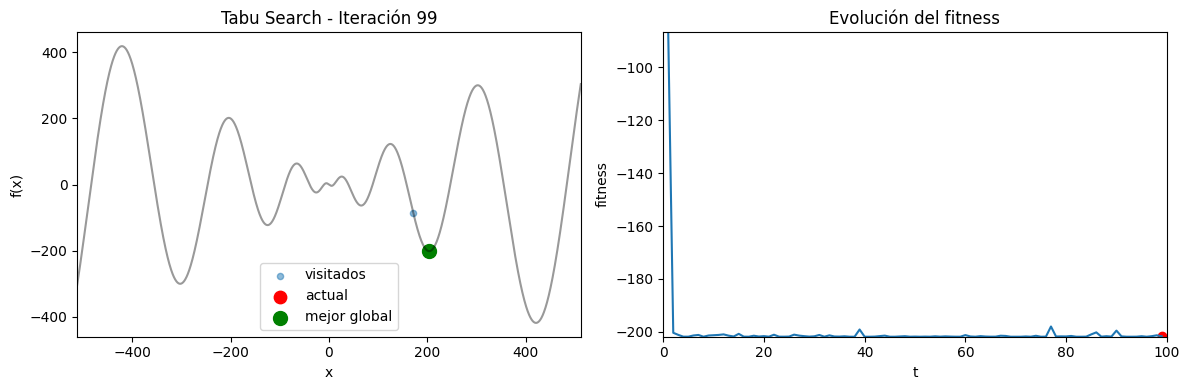

In [9]:
ts = tabu_search(
    function=f_1,
    start_point=[100],
    lower=[-512],
    upper=[512],
    k=20,
    n_vecinos=30,
    sigma=25,
    n_max=100,
    minimize=True
)

best_x, best_f = ts.run()

print(best_x, best_f)

animate_tabu_1d(
    ts,
    f_1,
    lower=-512,
    upper=512,
    sleep=0.1
)

### 2.2 Análisis de hiperparámetros en Schwefel 1D

Los dos hiperparámetros fundamentales de Tabu Search básico son el tamaño de la lista tabú (tenure) $k$ y el tamaño del vecindario $|N|$. El tenure controla el balance entre intensificación (valores pequeños permiten revisitar regiones rápidamente) y diversificación (valores grandes fuerzan exploración prolongada de nuevas regiones). El tamaño del vecindario determina qué tan exhaustivamente se explora el entorno local en cada iteración, afectando directamente el costo computacional.

#### Experimento 1: Tamaño de lista tabú (tenure)

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_1(x) = -x \cdot \sin(\sqrt{|x|}), \quad x \in [-512, 512] \\
\text{Hiperparámetros:} & \quad k \in \{5, 10, 20, 50, 100\} \\
& \quad |N| = 20 \text{ (fijo)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 1000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } k \\
\text{Inicialización:} & \quad \text{Aleatoria uniforme en } [-512, 512] \\
\text{Generación de vecinos:} & \quad x_i = x + \mathcal{N}(0, \sigma^2), \quad i=1,\ldots,20, \quad \sigma = 50
\end{aligned}
$$

In [10]:
def results_to_df(results, param_name, indexs):
    columns = [f"median_{param_name}", f"mean_{param_name}", f"std_{param_name}", f"min_{param_name}", f"max_{param_name}"]

    df = pd.DataFrame(
        data = {
            columns[0]: [np.median(results[index][f"best_{param_name}"]) for index in indexs],
            columns[1]: [np.mean(results[index][f"best_{param_name}"]) for index in indexs],
            columns[2]: [np.std(results[index][f"best_{param_name}"]) for index in indexs],
            columns[3]: [np.min(results[index][f"best_{param_name}"]) for index in indexs],
            columns[4]: [np.max(results[index][f"best_{param_name}"]) for index in indexs],

        },
        index = indexs
    )
    return df



In [11]:
k_s = [5,10,20,50,100]
N_max = 1000
cant_n = 20
inner_limit_x = -512
upper_limit_x = 512

sigma = 50

n_repeat= 10

results_exp1 = {}

for k in k_s:
    best_xs = []
    best_ys = []
    best_is = []
    best_total_ngh = []
    best_prob_tabu_accept = []
    for _ in range(n_repeat):
        start_point = [np.random.uniform(inner_limit_x, upper_limit_x)]
        opt = tabu_search(f_1, start_point, inner_limit_x, upper_limit_x,cant_n,k,sigma)

        best_x, best_fit = opt.run()
        best_xs.append(best_x)
        best_ys.append(best_fit)
        best_is.append(opt.best_iteration)
        best_total_ngh.append(opt.total_neighbors_evaluated)
        best_prob_tabu_accept.append(opt.prop_tabu)

    curr_dict = {
        "best_x": best_xs,
        "best_fit": best_ys,
        "best_iters": best_is,
        "best_total_nghb_evaluated": best_total_ngh,
        "best_props_to_tabu": best_prob_tabu_accept

    }
    results_exp1[k] = curr_dict


results_exp1



{5: {'best_x': [array([-302.51989844]),
   array([420.96766377]),
   array([-302.56378575]),
   array([420.97612711]),
   array([-302.49624234]),
   array([420.96159811]),
   array([-302.51771443]),
   array([-302.52813022]),
   array([420.98691274]),
   array([420.9704477])],
  'best_fit': [array([-300.54454944]),
   array([-418.98288712]),
   array([-300.54436151]),
   array([-418.9828804]),
   array([-300.54444839]),
   array([-418.98288082]),
   array([-300.54454605]),
   array([-300.54455137]),
   array([-418.98284563]),
   array([-418.98288691])],
  'best_iters': [320, 533, 971, 680, 1, 756, 494, 506, 461, 235],
  'best_total_nghb_evaluated': [4995,
   4995,
   4995,
   4995,
   4995,
   4995,
   4995,
   4995,
   4995,
   4995],
  'best_props_to_tabu': [0.0032032032032032033,
   0.003003003003003003,
   0.0018018018018018018,
   0.0036036036036036037,
   0.0038038038038038036,
   0.004004004004004004,
   0.0024024024024024023,
   0.0026026026026026027,
   0.0022022022022022024,


In [12]:
# seleccion del mejor k en funcion de la media
mean_fit_by_k = {}

for k, data in results_exp1.items():
    fits = np.array(data["best_fit"]).flatten()
    mean_fit = np.mean(fits)
    
    mean_fit_by_k[k] = mean_fit

# mejor k (como minimizás)
best_k = min(mean_fit_by_k, key=mean_fit_by_k.get)

print("Mean fitness por k:")
for k, mean_fit in mean_fit_by_k.items():
    print(f"k={k}: {mean_fit}")

print("\nMejor k:", best_k)
print("Mean fitness:", mean_fit_by_k[best_k])

Mean fitness por k:
k=5: -359.7636837646361
k=10: -348.288361688342
k=20: -361.60618148490937
k=50: -372.7130309520163
k=100: -338.2870109736344

Mejor k: 50
Mean fitness: -372.7130309520163


**Justificación del rango de tenure** (tamaño de la memoria): 
- $k = 5$: memoria muy corta, poco efecto de diversificación, comportamiento cercano a Hill Climbing
- $k = 20$: valor intermedio típico en literatura
- $k = 100$: memoria larga, fuerte diversificación, riesgo de prohibir regiones prometedoras demasiado tiempo

**Métricas registradas** (por cada repetición):
- Mejor fitness alcanzado
- Posición de mejor solución
- Iteración del mejor hallazgo
- Número total de vecinos evaluados
- Proporción promedio de vecinos que fueron tabú

> **Análisis de los resultados**: Idéntico al protocolo de SA: media, mediana, min, max, desviación estándar, organizados en tabla comparativa. Generar boxplots y gráficos de convergencia promedio.

In [13]:
display(results_to_df(results_exp1,"x", k_s))
display(results_to_df(results_exp1,"fit", k_s))
display(results_to_df(results_exp1,"iters", k_s))


,median_x,mean_x,std_x,min_x,max_x
5,59.232678,59.223698,361.748852,-302.563786,420.986913
10,-302.516266,-34.077420,376.428369,-512.000000,420.980244
20,-45.521449,-45.518822,466.481178,-512.000000,420.967240
50,420.967320,68.730202,435.202222,-512.000000,420.977528
100,-512.000000,-211.161820,418.346311,-512.000000,420.970262


,median_fit,mean_fit,std_fit,min_fit,max_fit
5,-359.763698,-359.763684,59.219192,-418.982887,-300.544362
10,-302.387018,-348.288362,57.731617,-418.982885,-300.544514
20,-361.606176,-361.606181,57.376699,-418.982887,-304.229483
50,-418.982881,-372.713031,56.677751,-418.982887,-300.544551
100,-304.229483,-338.287011,52.838866,-418.982887,-300.544553


,median_iters,mean_iters,std_iters,min_iters,max_iters
5,500.0,495.7,259.595859,1,971
10,497.5,479.1,293.923953,74,936
20,309.0,297.5,290.101103,1,913
50,509.0,529.6,249.803203,1,860
100,176.5,253.6,265.035922,1,676


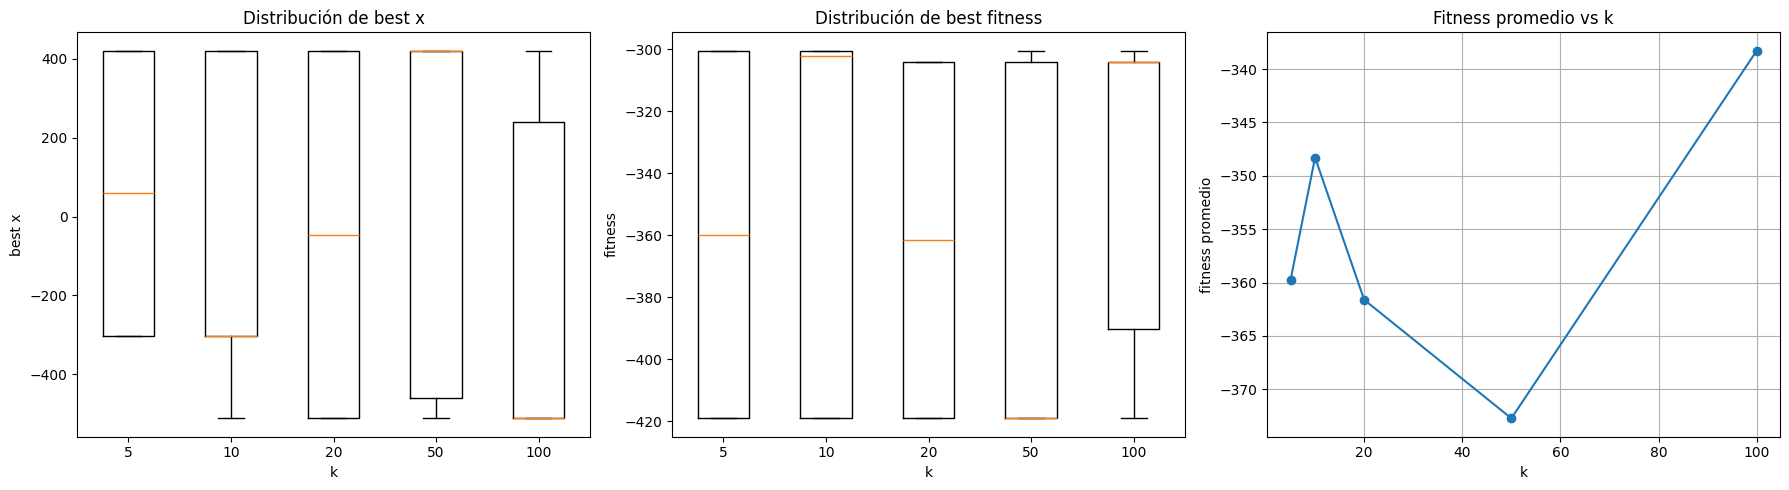

In [14]:

k_s = list(results_exp1.keys())

data_x = []
data_fit = []

for k in k_s:
    xs = np.array(results_exp1[k]["best_x"]).flatten()
    fits = np.array(results_exp1[k]["best_fit"]).flatten()
    
    data_x.append(xs)
    data_fit.append(fits)

# promedio fitness por k
mean_fitness = [np.mean(fits) for fits in data_fit]

fig, axs = plt.subplots(1, 3, figsize=(18,5))

# Boxplot best_x
axs[0].boxplot(data_x, tick_labels=k_s)
axs[0].set_title("Distribución de best x")
axs[0].set_xlabel("k")
axs[0].set_ylabel("best x")

# Boxplot best fitness
axs[1].boxplot(data_fit, tick_labels=k_s)
axs[1].set_title("Distribución de best fitness")
axs[1].set_xlabel("k")
axs[1].set_ylabel("fitness")

# Promedio fitness por k
axs[2].plot(k_s, mean_fitness, marker='o')
axs[2].set_title("Fitness promedio vs k")
axs[2].set_xlabel("k")
axs[2].set_ylabel("fitness promedio")
axs[2].grid(True)

plt.tight_layout()
plt.show()

De manera general se puede ver que, hay varianzas elevadas tanto para los resultados de la posicion x como la media de fitness.
A su vez, vemos que un k intermedio rinde mejor intermedio, entre poca y mucha memoria

In [15]:
display(results_to_df(results_exp1,"props_to_tabu", k_s))

,median_props_to_tabu,mean_props_to_tabu,std_props_to_tabu,min_props_to_tabu,max_props_to_tabu
5,0.003103,0.003003,0.000694,0.001802,0.004004
10,0.002953,0.004545,0.004888,0.002102,0.019119
20,0.035711,0.060911,0.064426,0.002603,0.168118
50,0.003303,0.033319,0.047332,0.002903,0.131251
100,0.046371,0.115584,0.130075,0.002943,0.365576


Experimento raro: K=100
- media de rechazo 6.9%
- desvio 0.14
- maximo 0.46!!!!!!!!!!casi la mitad de rechazo


**Preguntas de análisis**:

1. ¿Existe un valor óptimo de $k$ o el rendimiento es insensible al tenure en este rango?
2. ¿Tenure muy pequeño ($k=5$) resulta en estancamiento por falta de diversificación?
3. ¿Tenure muy grande ($k=100$) perjudica por prohibir regiones prometedoras?
4. ¿Cómo se relaciona la variabilidad de resultados con el tamaño del tenure?
5. ¿En qué momento de la ejecución típicamente se encuentra el mejor resultado para cada $k$?


#### Experimento 2: Tamaño de vecindario

> Emplee el valor de tenure identificado previamente (mantener fijo) y evalúe el impacto del tamaño del vecindario explorado en cada iteración.

**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp.1}] \text{ (fijo)} \\
& \quad |N| \in \{5, 10, 20, 50, 100\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$

**Observación importante sobre el número de evaluaciones**: El número total de evaluaciones de función objetivo varía con $|N|$:
- $|N| = 5$: $1000 \times 5 = 5000$ evaluaciones totales
- $|N| = 20$: $1000 \times 20 = 20000$ evaluaciones totales
- $|N| = 100$: $1000 \times 100 = 100000$ evaluaciones totales

Esto introduce un sesgo: configuraciones con $|N|$ mayor tienen más evaluaciones totales. Para una comparación completamente justa, se debería fijar el número total de evaluaciones y ajustar el número de iteraciones correspondientemente. Sin embargo, para este experimento preliminar se mantiene fijo el número de iteraciones para observar el trade-off entre amplitud de exploración local versus número de iteraciones.

In [16]:
import time
# seleccionamos el mejor valor de k
N_s = [5,10,20,50,100]

N_max = 1000
inner_limit_x = -512
upper_limit_x = 512

sigma = 50

n_repeat= 10
budget = 20000



results_exp2 = {}

for N in N_s:
    n_iter = budget//N
    best_xs = []
    best_ys = []
    best_is = []
    best_total_ngh = []
    best_prob_tabu_accept = []
    best_times = []
    for _ in range(n_repeat):
        start_point = [np.random.uniform(inner_limit_x, upper_limit_x)]
        start_time = time.time()
        opt = tabu_search(f_1, start_point, inner_limit_x, upper_limit_x,N,k,sigma, n_max=n_iter)
        end_time = time.time()

        elapsed_time = end_time - start_time

        best_x, best_fit = opt.run()
        best_xs.append(best_x)
        best_ys.append(best_fit)
        best_is.append(opt.best_iteration)
        best_total_ngh.append(opt.total_neighbors_evaluated)
        best_prob_tabu_accept.append(opt.prop_tabu)
        best_times.append(elapsed_time)

    curr_dict = {
        "best_x": best_xs,
        "best_fit": best_ys,
        "best_iters": best_is,
        "best_total_nghb_evaluated": best_total_ngh,
        "best_props_to_tabu": best_prob_tabu_accept,
        "best_times": best_times

    }
    results_exp2[N] = curr_dict


results_exp2





{5: {'best_x': [array([-512.]),
   array([-512.]),
   array([-512.]),
   array([420.96867842]),
   array([420.9689848]),
   array([420.96868671]),
   array([-512.]),
   array([-512.]),
   array([-512.]),
   array([-512.])],
  'best_fit': [array([-304.22948261]),
   array([-304.22948261]),
   array([-304.22948261]),
   array([-418.98288727]),
   array([-418.98288727]),
   array([-418.98288727]),
   array([-304.22948261]),
   array([-304.22948261]),
   array([-304.22948261]),
   array([-304.22948261])],
  'best_iters': [293, 14, 1, 2970, 1048, 505, 1, 181, 170, 661],
  'best_total_nghb_evaluated': [399900,
   399900,
   399900,
   399900,
   399900,
   399900,
   399900,
   399900,
   399900,
   399900],
  'best_props_to_tabu': [0.039132283070767694,
   0.3217104276069017,
   0.25291822955738935,
   0.0008577144286071518,
   0.0008102025506376594,
   0.0007851962990747687,
   0.3449612403100775,
   0.13094273568392098,
   0.23832708177044262,
   0.25161290322580643],
  'best_times': [0.0

In [17]:
# seleccion del mejor n en funcion de la media
mean_fit_by_n = {}

for n, data in results_exp2.items():
    fits = np.array(data["best_fit"]).flatten()
    mean_fit = np.mean(fits)
    
    mean_fit_by_n[n] = mean_fit

# mejor n (como minimizás)
best_n = min(mean_fit_by_n, key=mean_fit_by_n.get)

print("Mean fitness por n:")
for n, mean_fit in mean_fit_by_n.items():
    print(f"n={n}: {mean_fit}")

print("\nMejor n:", best_n)
print("Mean fitness:", mean_fit_by_n[best_k])

Mean fitness por n:
n=5: -338.6555040104918
n=10: -350.13084446338553
n=20: -361.2376918934475
n=50: -349.7623511214
n=100: -337.18152900939054

Mejor n: 20
Mean fitness: -349.7623511214


In [18]:
display(results_to_df(results_exp2,"x", k_s))
display(results_to_df(results_exp2,"fit", k_s))
display(results_to_df(results_exp2,"iters", k_s))


,median_x,mean_x,std_x,min_x,max_x
5,-512.000000,-232.109365,427.540007,-512.0,420.968985
10,-512.000000,-138.812538,457.059430,-512.0,420.969059
20,59.222029,-24.567824,449.459270,-512.0,420.970452
50,-407.262783,-117.865552,444.091592,-512.0,420.970513
100,-302.519433,-148.316739,382.645077,-512.0,420.973835


,median_fit,mean_fit,std_fit,min_fit,max_fit
5,-304.229483,-338.655504,52.586616,-418.982887,-304.229483
10,-304.229483,-350.130844,56.217458,-418.982887,-304.229483
20,-361.606185,-361.237692,57.754600,-418.982887,-300.544553
50,-304.229483,-349.762351,56.528340,-418.982887,-300.544553
100,-304.229483,-337.181529,53.573287,-418.982885,-300.544542


,median_iters,mean_iters,std_iters,min_iters,max_iters
5,237.0,584.4,856.949497,1,2970
10,975.0,1039.5,617.652532,155,1991
20,254.5,294.2,283.172315,1,763
50,170.5,180.4,112.733491,5,376
100,63.0,62.4,44.732986,1,151


N mayor incrementa la varianza de losresultados y se alejan en promedio. El mejor resultado es n=10

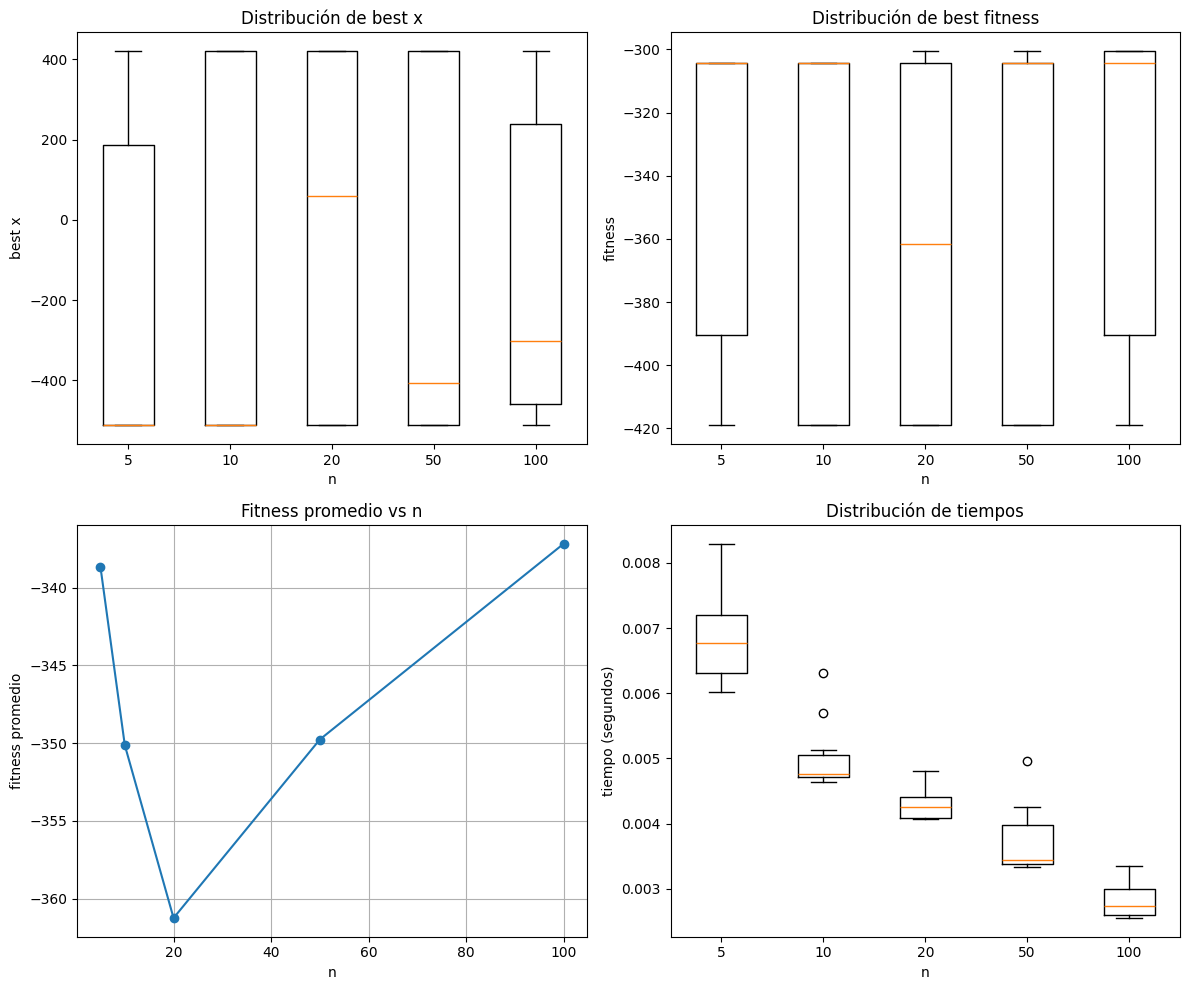

In [19]:
k_s = list(results_exp2.keys())

data_x = []
data_fit = []
data_time = []

for n in N_s:
    xs = np.array(results_exp2[n]["best_x"]).flatten()
    fits = np.array(results_exp2[n]["best_fit"]).flatten()
    times = np.array(results_exp2[n]["best_times"]).flatten()
    
    data_x.append(xs)
    data_fit.append(fits)
    data_time.append(times)

# promedio fitness por n
mean_fitness = [np.mean(fits) for fits in data_fit]

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# ----------------------
# arriba izquierda
axs[0,0].boxplot(data_x, tick_labels=k_s)
axs[0,0].set_title("Distribución de best x")
axs[0,0].set_xlabel("n")
axs[0,0].set_ylabel("best x")

# ----------------------
# arriba derecha
axs[0,1].boxplot(data_fit, tick_labels=k_s)
axs[0,1].set_title("Distribución de best fitness")
axs[0,1].set_xlabel("n")
axs[0,1].set_ylabel("fitness")

# ----------------------
# abajo izquierda
axs[1,0].plot(k_s, mean_fitness, marker='o')
axs[1,0].set_title("Fitness promedio vs n")
axs[1,0].set_xlabel("n")
axs[1,0].set_ylabel("fitness promedio")
axs[1,0].grid(True)

# ----------------------
# abajo derecha
axs[1,1].boxplot(data_time, tick_labels=k_s)
axs[1,1].set_title("Distribución de tiempos")
axs[1,1].set_xlabel("n")
axs[1,1].set_ylabel("tiempo (segundos)")

plt.tight_layout()
plt.show()


**Preguntas de análisis**:

1. ¿Mayor $|N|$ siempre resulta en mejor rendimiento, o existe un punto de rendimientos decrecientes?
2. ¿Cómo afecta $|N|$ al tiempo de ejecución?
3. ¿El $|N|$ óptimo depende del valor de $k$ elegido?
4. ¿Explorar vecindarios muy grandes ($|N|=100$) en cada iteración es computacionalmente justificable?


A mayor|N| mayor varianza y pero rendimiento.
EL tiempo se reduce a mayor N?

### 2.3 Aplicación a la función 2D

Los experimentos previos en la función unidimensional de Schwefel han permitido identificar configuraciones óptimas de los hiperparámetros $k$ (tenure) y $|N|$ (tamaño de vecindario) para *Tabu Search*. En esta sección se aplicará el algoritmo a la función $f_2(x,y)$, adaptando la implementación al espacio bidimensional y evaluando el impacto de los hiperparámetros en un paisaje de fitness con estructura radial y alta multimodalidad.

#### Adaptaciones necesarias para 2D

**Operador de vecindario bidimensional**: La generación de vecinos en $\mathbb{R}^2$ se realiza mediante perturbación Gaussiana independiente en cada dimensión. Para cada iteración, se generan $|N|$ vecinos candidatos:

$$\begin{pmatrix} x'_i \\ y'_i \end{pmatrix} = \begin{pmatrix} x \\ y \end{pmatrix} + \begin{pmatrix} \delta_{x,i} \\ \delta_{y,i} \end{pmatrix}, \quad \delta_{x,i}, \delta_{y,i} \sim \mathcal{N}(0, \sigma^2), \quad i = 1, \ldots, |N|$$

donde $\sigma$ es la desviación estándar que controla el tamaño del paso de búsqueda. Un valor apropiado inicial para la función $f_2(x,y)$ con dominio $[-100, 100]^2$, es $\sigma = 10.0$, consistente con el valor empleado en *Simulated Annealing*. Este valor permite exploración efectiva del espacio sin generar pasos excesivamente grandes que dificulten la convergencia.

**Manejo de restricciones del dominio**: Cuando la perturbación genera un candidato $(x'_i, y'_i)$ que viola las restricciones del dominio, se aplica la estrategia de **proyección al borde**: si $x'_i < -100$ se fija $x'_i = -100$, si $x'_i > 100$ se fija $x'_i = 100$, y análogamente para $y'_i$. Esto garantiza que todos los candidatos evaluados sean factibles.

**Representación de la lista tabú en 2D**: La lista tabú almacena puntos $(x, y)$ recientemente visitados. Dado que trabajamos con números reales de punto flotante, dos soluciones se consideran equivalentes si su distancia euclidiana es menor que una tolerancia $\varepsilon$:

$$\text{is\_tabu}((x', y')) = \exists (x_t, y_t) \in \text{TabuList} : \sqrt{(x' - x_t)^2 + (y' - y_t)^2} < \varepsilon$$

Para la función $f_2(x,y)$, se empleará $\varepsilon = 1.0$ como criterio de proximidad, representando aproximadamente el 1% del rango del dominio.


In [20]:
#vamos a probar un ejemplo

start_point = [2.5, -3.0]

opt = tabu_search(
    function=f_2,
    start_point=start_point,
    lower=[-100, -100],
    upper=[100, 100],
    k=20,
    n_vecinos=30,
    sigma=5,
    epsilon=0.1,
    n_max=500,
    minimize=True
)

best_point, best_fitness = opt.run()

print("Mejor punto:", best_point)
print("Mejor fitness:", best_fitness)
print("Iteración mejor:", opt.best_iteration)
print("Vecinos evaluados:", opt.total_neighbors_evaluated)
print("Proporción tabú:", opt.prop_tabu)

Mejor punto: [-0.05485088  0.02418088]
Mejor fitness: 0.25491711149533025
Iteración mejor: 23
Vecinos evaluados: 14970
Proporción tabú: 0.0029392117568470275


**Visualización en 2D**:

- **Gráfico de contorno** (contour plot) de $f_2(x,y)$ en el dominio $[-100,100]^2$ como referencia estática de fondo
- **Soluciones tabú**: marcadores semi-transparentes en color mostrando las posiciones actualmente en la lista tabú, permitiendo visualizar qué regiones están temporalmente prohibidas
- **Posición actual**: marcador de color que muestra la ubicación de la solución actual $(x_{\text{current}}, y_{\text{current}})$
- **Mejor posición**: marcador de color en forma de estrella que indica $(x_{\text{best}}, y_{\text{best}})$
- **Óptimo global conocido**: marcador negro en el origen $(0, 0)$ para referencia

Esta visualización permite observar cómo la memoria explícita de Tabu Search moldea la trayectoria de búsqueda en el paisaje radial, y evaluar si el algoritmo logra aproximarse sistemáticamente al óptimo global.

In [21]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib as mpl
mpl.rcParams['animation.embed_limit'] = 200  
def animate_tabu_search(opt, function):

    # ---------------------------
    # Contour de fondo
    # ---------------------------
    x = np.linspace(-100, 100, 200)
    y = np.linspace(-100, 100, 200)
    X, Y = np.meshgrid(x, y)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i,j] = function([X[i,j], Y[i,j]])

    fig, ax = plt.subplots(figsize=(8,8))

    contour = ax.contour(
        X, Y, Z,
        levels=30,
        cmap='viridis'
    )

    ax.set_xlim(-10,50)
    ax.set_ylim(-10,50)

    ax.set_title("Tabu Search")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    # óptimo global
    ax.scatter(
        0,0,
        color="black",
        marker="x",
        s=150,
        label="Óptimo global"
    )

    # elementos dinámicos
    tabu_scatter = ax.scatter([], [], c='red', alpha=0.3, s=60, label="Tabú")
    current_scatter = ax.scatter([], [], c='blue', s=120, label="Actual")
    best_scatter = ax.scatter([], [], c='gold', marker='*', s=250, label="Mejor")

    ax.legend()

    # ---------------------------
    # Función update
    # ---------------------------
    def update(frame):

        current = opt.hist_points[frame]

        # mejor hasta frame actual
        best_idx = np.argmin(opt.hist_fitness[:frame+1])
        best = opt.hist_points[best_idx]

        # lista tabu actual
        tabu_points = opt.hist_tabu[frame]

        if len(tabu_points) > 0:
            tabu_array = np.array(tabu_points)
            tabu_scatter.set_offsets(tabu_array[:, :2])
        else:
            tabu_scatter.set_offsets(np.empty((0,2)))

        current_scatter.set_offsets([current[:2]])
        best_scatter.set_offsets([best[:2]])

        ax.set_title(f"Iteración {frame+1}")

        return tabu_scatter, current_scatter, best_scatter

    anim = FuncAnimation(
        fig,
        update,
        frames=len(opt.hist_points),
        interval=100,
        repeat=False
    )

    #plt.show()
    HTML(anim.to_jshtml())

In [22]:
#best_point, best_fitness = opt.run()
#animate_tabu_search(opt, f_2)

#### Experimento 1: Calibración del tamaño de lista tabú (tenure) en 2D

El primer paso es determinar si el tenure óptimo identificado en Schwefel 1D es apropiado para la función de Oscilación Radial, considerando que el espacio de búsqueda bidimensional presenta mayor complejidad y un número mayor de regiones locales que pueden ser visitadas.

**Configuración experimental**:

$$
\begin{aligned}
\text{Función:} & \quad f_2(x,y) = (x^{2} + y^{2})^{0.25} \cdot [\sin^{2}(50 \cdot (x^{2} + y^{2})^{0.1}) + 1] \\
\text{Dominio:} & \quad (x,y) \in [-100, 100]^2 \\
\text{Hiperparámetros:} & \quad k \in \{5, 10, 20, 50, 100\} \\
& \quad |N| = [|N|_{\text{óptimo}} \text{ de Exp. 2.3.2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (desviación estándar de perturbación)} \\
& \quad \varepsilon = 1.0 \text{ (tolerancia para comparación tabú)} \\
\text{Iteraciones:} & \quad N_{\text{max}} = 2000 \\
\text{Repeticiones:} & \quad 10 \text{ ejecuciones independientes por cada } k \\
\text{Inicialización:} & \quad (x_0, y_0) \text{ aleatorio uniforme en } [-100, 100]^2
\end{aligned}
$$

In [27]:
k_s = [5, 10, 20, 50, 100]
sigma = 10

lower = [-100, -100]
upper = [100, 100]

eps = 1
n_vecinos = 30
N_max = 2000
n_repeat = 10

results_exp3 = {}

for k in k_s:

    best_xs = []
    best_fits = []
    best_iters = []
    best_total_ngh = []
    best_prob_tabu = []
    best_times = []
    best_distances = []

    for _ in range(n_repeat):

        start_point = [
            np.random.uniform(-100, 100),
            np.random.uniform(-100, 100)
        ]

        opt = tabu_search(
            function=f_2,
            start_point=start_point,
            lower=lower,
            upper=upper,
            k=k,
            n_vecinos=n_vecinos,
            sigma=sigma,
            epsilon=eps,
            n_max=N_max,
            minimize=True
        )

        start_time = time.time()
        best_x, best_fit = opt.run()
        end_time = time.time()

        elapsed_time = end_time - start_time

        best_xs.append(best_x)
        best_fits.append(best_fit)
        best_iters.append(opt.best_iteration)
        best_total_ngh.append(opt.total_neighbors_evaluated)
        best_prob_tabu.append(opt.prop_tabu)
        best_times.append(elapsed_time)
        best_distances.append(opt.distance_to_optimum)

    results_exp3[k] = {
        "best_x": best_xs,
        "best_fit": best_fits,
        "best_iters": best_iters,
        "best_total_nghb_evaluated": best_total_ngh,
        "best_props_to_tabu": best_prob_tabu,
        "best_times": best_times,
        "best_optimum": best_distances
    }

**Justificación del rango de tenure**:
- $k = 5$: memoria muy corta, permite revisitar regiones rápidamente, riesgo de ciclos
- $k = 20$: memoria intermedia, balance típico en literatura
- $k = 50$: memoria larga, fuerte diversificación
- $k = 100$: memoria muy larga, riesgo de excesiva prohibición de regiones prometedoras

En 2D, el espacio de búsqueda es considerablemente más amplio que en 1D, lo que podría requerir tenures más largos para evitar ciclos efectivamente. Sin embargo, tenures excesivos pueden prohibir prematuramente regiones cercanas al óptimo global.


**Métricas a registrar** (para cada una de las 10 repeticiones de cada configuración):

1. **Mejor fitness alcanzado**: $f_2(x_{\text{best}}, y_{\text{best}})$
2. **Posición de la mejor solución**: $(x_{\text{best}}, y_{\text{best}})$
3. **Distancia euclidiana al óptimo global**: $d = \sqrt{x_{\text{best}}^2 + y_{\text{best}}^2}$
4. **Iteración en que se encontró el mejor**: $t_{\text{best}}$
6. **Número total de evaluaciones**: $N_{\text{max}} \times |N|$ (debería ser constante)
7. **Proporción promedio de vecinos tabú**: fracción del vecindario generado que fue rechazado por estar en la lista tabú

> Para cada valor de $k$, calcular sobre las 10 repeticiones:
> - Media aritmética de $f_{\text{best}}$
> - Mediana, mínimo y máximo de $f_{\text{best}}$
> - Desviación estándar
> - Media de la distancia al óptimo $\bar{d}$
> - Proporción promedio de vecinos tabú
> Presentar los resultados en una **tabla comparativa**:


In [37]:


def results_to_df_2(results, param_name, indexs):

    def summarize(values):
        arr = np.array(values)

        if arr.ndim == 2:  # vectores (x,y)
            return {
                "median": np.round(np.median(arr, axis=0), 4),
                "mean":   np.round(np.mean(arr, axis=0), 4),
                "std":    np.round(np.std(arr, axis=0), 4),
                "min":    np.round(np.min(arr, axis=0), 4),
                "max":    np.round(np.max(arr, axis=0), 4),
            }

        # escalares
        return {
            "median": round(np.median(arr), 4),
            "mean":   round(np.mean(arr), 4),
            "std":    round(np.std(arr), 4),
            "min":    round(np.min(arr), 4),
            "max":    round(np.max(arr), 4),
        }

    rows = []

    for k in indexs:
        stats = summarize(results[k][f"best_{param_name}"])

        rows.append({
            f"median_{param_name}": stats["median"],
            f"mean_{param_name}": stats["mean"],
            f"std_{param_name}": stats["std"],
            f"min_{param_name}": stats["min"],
            f"max_{param_name}": stats["max"],
        })

    return pd.DataFrame(rows, index=indexs)

In [38]:
display(results_to_df_2(results_exp3, "x", k_s))
display(results_to_df_2(results_exp3, "fit", k_s))
display(results_to_df_2(results_exp3, "iters", k_s))

,median_x,mean_x,std_x,min_x,max_x
5,"[0.0006, 0.0386]","[0.0051, 0.0157]","[0.0798, 0.0787]","[-0.1482, -0.1211]","[0.1312, 0.1291]"
10,"[-0.0044, 0.0212]","[-0.0066, 0.0141]","[0.1115, 0.075]","[-0.1512, -0.162]","[0.1795, 0.1027]"
20,"[-0.0198, -0.0511]","[-0.0112, -0.0595]","[0.1689, 0.0893]","[-0.3627, -0.2125]","[0.2458, 0.0768]"
50,"[-0.0224, 0.0092]","[-0.0057, -0.0197]","[0.1295, 0.1265]","[-0.2363, -0.2423]","[0.2203, 0.1504]"
100,"[-0.0304, 0.0097]","[-0.0342, 0.0036]","[0.1202, 0.1292]","[-0.2409, -0.2307]","[0.196, 0.1909]"


,median_fit,mean_fit,std_fit,min_fit,max_fit
5,0.3462,0.3399,0.0857,0.1942,0.4899
10,0.4194,0.3684,0.1202,0.0921,0.4934
20,0.4428,0.4474,0.0916,0.3124,0.6047
50,0.4345,0.4451,0.0803,0.3146,0.5885
100,0.4932,0.4433,0.1101,0.1900,0.5427


,median_iters,mean_iters,std_iters,min_iters,max_iters
5,784.5,839.9,559.4491,34,1809
10,1401.5,1203.9,563.2297,151,1959
20,747.5,802.1,620.8203,5,1753
50,726.0,693.9,476.3899,6,1551
100,1147.0,1025.3,502.0229,156,1655



| $k$ | Media | Mediana | Mín | Máx | Dist. promedio | % Tabú |
|-----|:-----:|---------|-----|-----|----------------|--------|
| 5   | ...   | ...     | ... | ... | ...            | ...    |
| 10  | ...   | ...     | ... | ... | ...            | ...    |
| 20  | ...   | ...     | ... | ... | ...            | ...    |
| 50  | ...   | ...     | ... | ... | ...            | ...    |
| 100 | ...   | ...     | ... | ... | ...            | ...    |



> Adicionalmente, generar visualizaciones complementarias:
> 1. **Boxplot comparativo**: Un gráfico de boxplot que muestre, para cada valor de $k$, la distribución de los mejores fitness alcanzados.
> 2. **Scatter plot de posiciones finales**: Sobre un contour plot de la función, marcar las 10 posiciones finales $(x_{\text{best}}, y_{\text{best}})$ de cada configuración con diferentes colores. Incluir un círculo en el origen y círculos concéntricos a distancias 10, 25, 50 como referencia visual. Opcionalmente, puede utilizar una proyección superior de la función $f_2(x,y)$ para ubicar los puntos.
> 3. **Gráfico de convergencia promedio**: Para cada $k$, graficar la evolución del fitness promedio (promediado sobre las 10 repeticiones) vs iteración.
> 4. **Proporción de vecinos tabú vs tenure**: Gráfico de barras mostrando el porcentaje promedio de vecinos rechazados para cada valor de $k$, permitiendo cuantificar el efecto de diversificación.


**Preguntas de análisis**:

1. ¿Qué valor de $k$ produce el mejor rendimiento promedio en términos de fitness alcanzado?
2. ¿El tenure óptimo en 2D coincide con el identificado en Schwefel 1D, o requiere ajuste? ¿El espacio 2D requiere memoria más larga?
3. ¿Cómo se relaciona la proporción de vecinos tabú con la calidad de las soluciones finales? ¿Mayor prohibición mejora o perjudica el rendimiento?
4. ¿Tenures muy pequeños ($k = 5$) resultan en ciclos observables en las visualizaciones? ¿Tenures muy grandes ($k = 100$) impiden acercarse al óptimo?
5. ¿Cuántas de las 10 repeticiones de cada configuración logran encontrar soluciones dentro de un radio $d < 10$ del óptimo?

#### Experimento 2: Calibración del tamaño de vecindario en 2D

El tamaño del vecindario $|N|$ determina cuán exhaustivamente se explora el entorno local de la solución actual en cada iteración. En problemas 2D, un vecindario más amplio puede ser necesario para capturar adecuadamente la estructura del paisaje, pero incrementa proporcionalmente el costo computacional por iteración.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad |N| \in \{10, 20, 30, 50, 100\} \\
& \quad \sigma = 10.0 \text{ (fijo)} \\
& \quad \varepsilon = 1.0 \text{ (fijo)} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$


**Justificación del rango de $|N|$**:
- $|N| = 10$: exploración local limitada, pocas opciones por iteración
- $|N| = 30$: exploración moderada, balance razonable
- $|N| = 100$: exploración exhaustiva del entorno local, alto costo computacional

**Observación crítica sobre presupuesto computacional**: A diferencia del Experimento 1 donde el número total de evaluaciones era constante, aquí varía con $|N|$:

- $|N| = 10$: $2000 \times 10 = 20{,}000$ evaluaciones totales
- $|N| = 50$: $2000 \times 50 = 100{,}000$ evaluaciones totales
- $|N| = 100$: $2000 \times 100 = 200{,}000$ evaluaciones totales

Esta variación introduce un sesgo: configuraciones con mayor $|N|$ tienen más evaluaciones disponibles. Sin embargo, este experimento busca evaluar el trade-off entre amplitud de exploración local versus número de iteraciones, por lo que se mantiene fijo $N_{\text{max}}$ en lugar del presupuesto total.


> Aplicar el mismo protocolo estadístico del Experimento 1, prestando especial atención a:
> - **Relación costo-beneficio**: ¿El incremento en calidad de soluciones justifica el incremento en evaluaciones?
> - **Tiempo de ejecución**: ¿Cómo escala el tiempo con $|N|$?
> - **Proporción de vecinos tabú**: ¿Vecindarios grandes resultan en mayor o menor proporción de candidatos prohibidos?
> Adicionalmente, para cada valor de $|N|$, calcular:
> - **Número promedio de mejoras por iteración**: frecuencia con que se actualiza $f_{\text{best}}$
> - **Eficiencia computacional**: calidad de solución alcanzada por cada 10000 evaluaciones (puede construir un gráfico de barras mostrando los valores calculados, comparando para los distintos $|N|$ analizados)


**Preguntas de análisis**:
1. ¿Qué valor de $|N|$ produce el mejor balance entre calidad de soluciones y costo computacional?
2. ¿Existe un punto de rendimientos decrecientes donde incrementar $|N|$ no mejora sustancialmente los resultados?
3. ¿Cómo interactúa $|N|$ con el tenure $k$? ¿Vecindarios grandes requieren tenures diferentes?
4. Observando el tiempo de ejecución, ¿es práctico usar $|N| = 100$ considerando el beneficio marginal obtenido?
5. Comparando con el Experimento 2.3.2 en Schwefel 1D, ¿el tamaño de vecindario óptimo es diferente en 2D?

#### Experimento 3: Impacto de la tolerancia de proximidad ($\varepsilon$)

El parámetro $\varepsilon$ determina cuán estricta es la comparación de proximidad al verificar si un candidato está en la lista tabú. Un $\varepsilon$ muy pequeño puede permitir que soluciones muy cercanas (pero no idénticas) sean consideradas diferentes, potencialmente causando ciclos. Un $\varepsilon$ muy grande puede prohibir excesivamente regiones amplias alrededor de cada punto tabú.


**Configuración experimental**:

$$
\begin{aligned}
\text{Hiperparámetros:} & \quad k = [k_{\text{óptimo}} \text{ del Exp. 1}] \text{ (fijo)} \\
& \quad |N| = [|N|_{\text{óptimo}} \text{ del Exp. 2}] \text{ (fijo)} \\
& \quad \sigma = 10.0 \text{ (fijo)} \\
& \quad \varepsilon \in \{0.1, 0.5, 1.0, 2.0, 5.0\} \\
\text{Protocolo:} & \quad \text{Idéntico al Experimento 1}
\end{aligned}
$$



**Justificación del rango de $\varepsilon$**:
- $\varepsilon = 0.1$: tolerancia muy estricta, solo puntos casi idénticos son considerados tabú
- $\varepsilon = 1.0$: tolerancia moderada (~1% del dominio)
- $\varepsilon = 5.0$: tolerancia amplia (~5% del dominio), prohibición de regiones grandes


> Aplicar el mismo protocolo estadístico que el los experimentos anteriores.


**Preguntas de análisis**:

1. ¿Qué valor de $\varepsilon$ produce el mejor equilibrio entre evitar ciclos y permitir refinamiento local?
2. ¿Tolerancias muy estrictas ($\varepsilon = 0.1$) resultan en comportamiento cualitativamente similar a no tener lista tabú?
3. ¿Tolerancias muy amplias ($\varepsilon = 5.0$) impiden convergencia fina al óptimo por prohibición excesiva?
4. ¿El efecto de $\varepsilon$ es más pronunciado con tenures grandes o pequeños?
5. Observando las visualizaciones, ¿cómo afecta $\varepsilon$ a los patrones espaciales de la búsqueda?


#### Análisis integrador

Una vez completados los tres experimentos, se debe realizar una síntesis que responda:

1. **Transferencia de hiperparámetros**: ¿Los valores óptimos de $k$ y $|N|$ identificados en Schwefel 1D transfieren efectivamente a la función $f_2(x,y)$ 2D, o requieren ajuste sustancial? ¿La dimensionalidad afecta más al tenure o al tamaño de vecindario?

2. **Rol de la tolerancia de proximidad**: ¿El parámetro $\varepsilon$ tiene un impacto comparable a $k$ y $|N|$ en el rendimiento, o su efecto es secundario? ¿Es posible identificar un valor $\varepsilon$ "universal" apropiado, o debe ajustarse según la función?

3. **Desafíos de dimensionalidad**: ¿La función 2D presenta desafíos cualitativamente diferentes a la 1D para Tabu Search? Por ejemplo, ¿la memoria tabú es más o menos efectiva en 2D para evitar ciclos? ¿La proporción de vecinos tabú es mayor o menor?

4. **Visualización del comportamiento**: Basándose en las visualizaciones construidas durante los experimentos, describir cualitativamente cómo Tabu Search navega el paisaje radial con oscilaciones. ¿Las prohibiciones tabú crean patrones espaciales reconocibles (ej: trayectorias que evitan sistemáticamente ciertas regiones)? ¿El algoritmo exhibe comportamiento exploratorio continuo o tiende a estabilizarse en regiones específicas?

5. **Comparación con Simulated Annealing**: Contrastar cualitativamente el comportamiento de Tabu Search en 2D (basándose en visualizaciones y métricas) con el comportamiento de Simulated Annealing (Sección 1.4). ¿Cuál algoritmo parece navegar más eficientemente el paisaje de la función $f_2(x,y)$? ¿Las trayectorias de búsqueda son cualitativamente diferentes?



---